In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

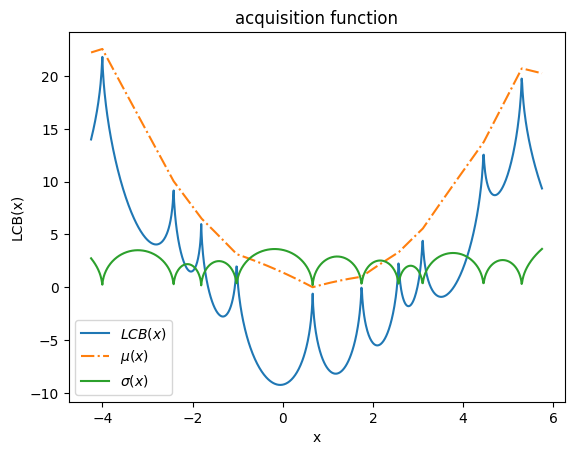

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 50
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)


for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU,l=li,u=ui)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = acqf.evaluate_meansig2(np.atleast_1d(mu_L), np.atleast_1d(s2_U))[0]
        LCB_U = acqf.evaluate_meansig2(np.atleast_1d(mu_U), np.atleast_1d(s2_L))[0]
        #LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        #LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

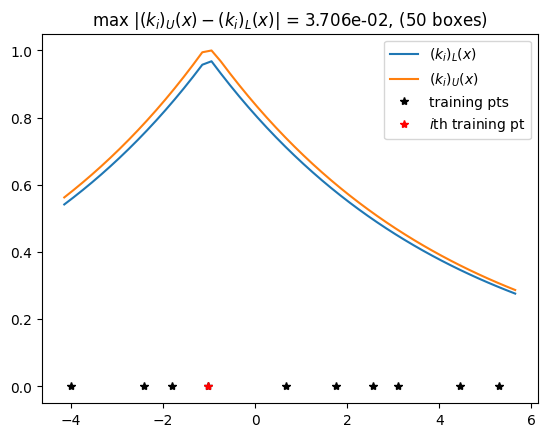

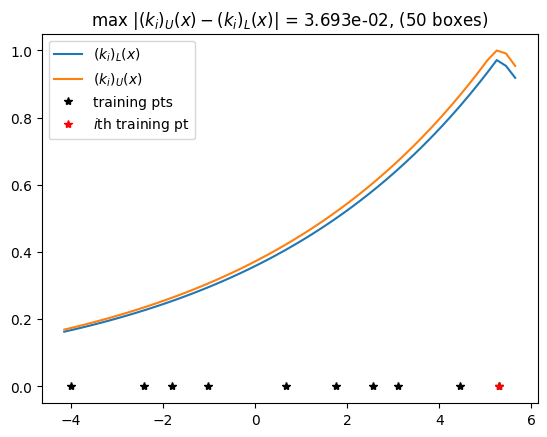

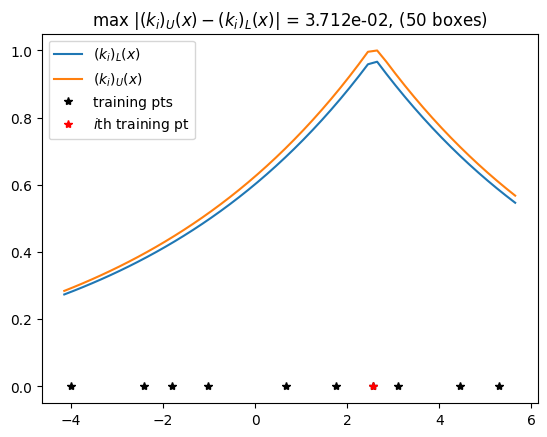

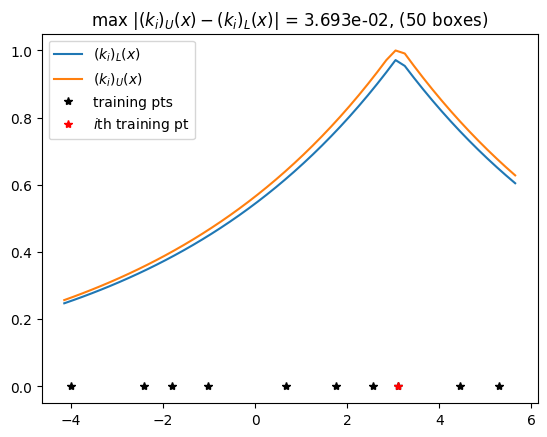

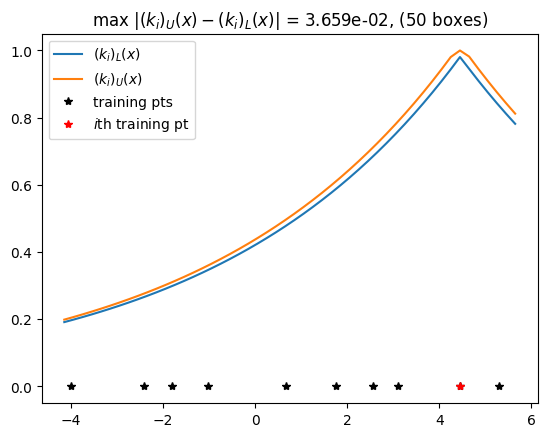

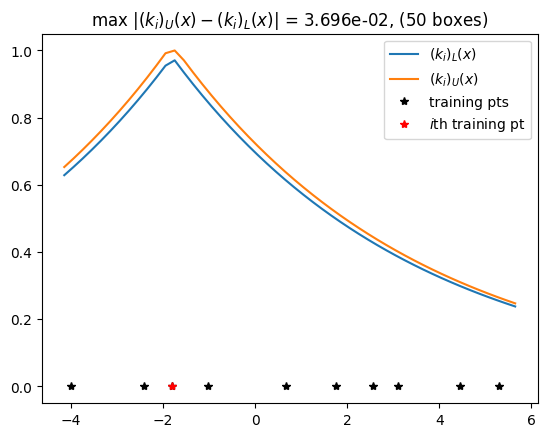

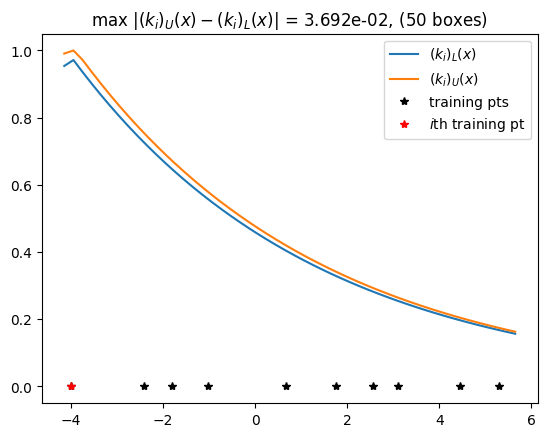

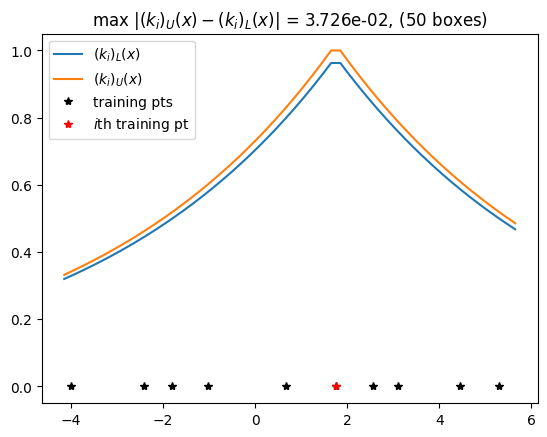

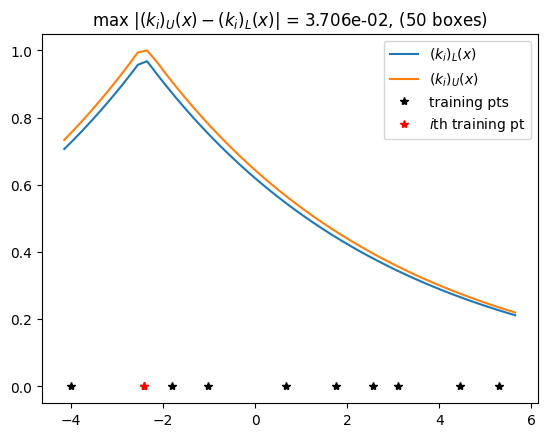

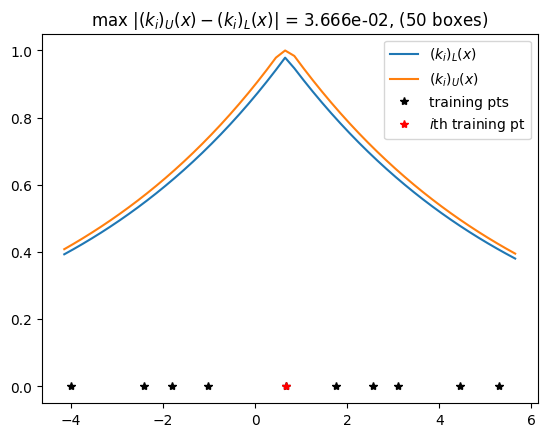

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

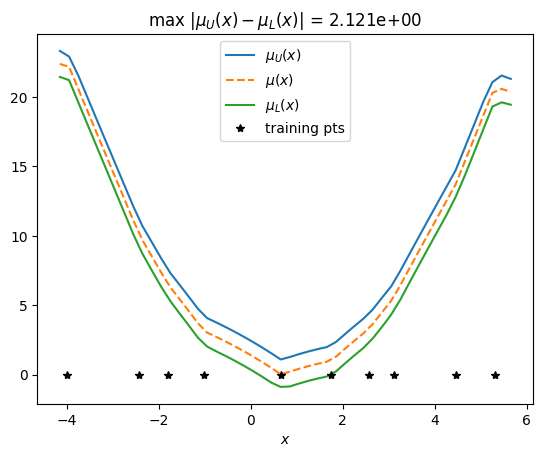

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

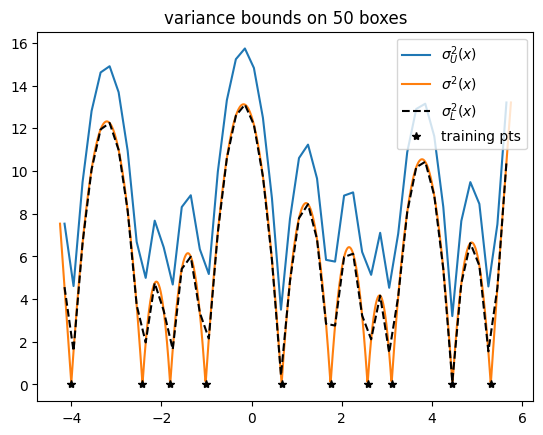

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(X, sigmaX**2., label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, "k--", label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

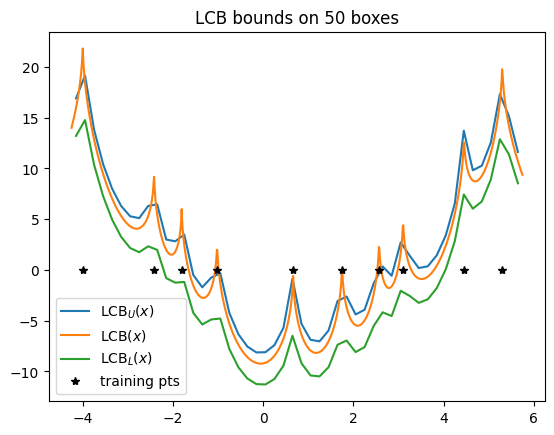

In [8]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [9]:
from hiopbbpy.opt import BnBAlgorithm

solver_options = {
    'epsilon_diam' : 1.e-12,
    'epsilon_gap' : 1.e-2,    
    'max_iter': 4000,
}


bnb = BnBAlgorithm(acqf, options=solver_options)
xstar = bnb.optimize()

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -54.68337151296102
Initial acquisition upper bound: -4.630063960995482

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-54.68337151296102, U=-4.630063960995482
Current best feasible value (LUB): -4.630063960995482
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-35.82614590980294, U=2.4507696194223185
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-36.472996891170176, U=0.36142948743758474
Queue size: 2 | LB=-36.472996891170176 | LUB=-4.630063960995482 | Gap<=31.842932930174694

--- BnB Iteration 2 ---
Node bounds: l=[0.75], u=[5.75]
Node acquisition bounds: L=-36.472996891170176, U=0.36142948743758474
Current best feasible value (LUB): -4.630063960995482
  Branching to child: l=[0.75], u=[3.25]
  Child acquisition bounds: L=-28.059624609369

  Child acquisition bounds: L=-2.7548175986823704, U=4.370258500287894
  Child pruned: L ≥ LUB + eps.
Queue size: 13 | LB=-11.043208600138902 | LUB=-9.237696244233318 | Gap<=1.8055123559055843

--- BnB Iteration 23 ---
Node bounds: l=[0.75], u=[1.0625]
Node acquisition bounds: L=-11.043208600138902, U=-7.0071242825968065
Current best feasible value (LUB): -9.237696244233318
  Branching to child: l=[0.75], u=[0.90625]
  Child acquisition bounds: L=-8.386508049262257, U=-6.078929964375643
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.90625], u=[1.0625]
  Child acquisition bounds: L=-9.615456371619452, U=-7.617483046749843
Queue size: 13 | LB=-10.860168601782028 | LUB=-9.237696244233318 | Gap<=1.6224723575487108

--- BnB Iteration 24 ---
Node bounds: l=[-0.1875], u=[-0.03125]
Node acquisition bounds: L=-10.860168601782028, U=-9.219340567608807
Current best feasible value (LUB): -9.237696244233318
  Branching to child: l=[-0.1875], u=[-0.109375]
  Child acquisition bounds: L=-1

  Child acquisition bounds: L=-8.362302384037763, U=-7.337397709369453
  Child pruned: L ≥ LUB + eps.
Queue size: 19 | LB=-9.61726262059807 | LUB=-9.24178014942833 | Gap<=0.37548247116973954

--- BnB Iteration 44 ---
Node bounds: l=[-0.1484375], u=[-0.109375]
Node acquisition bounds: L=-9.61726262059807, U=-9.200463027171057
Current best feasible value (LUB): -9.24178014942833
  Branching to child: l=[-0.1484375], u=[-0.12890625]
  Child acquisition bounds: L=-9.39783712039021, U=-9.188907188372713
  Branching to child: l=[-0.12890625], u=[-0.109375]
  Child acquisition bounds: L=-9.419761877540607, U=-9.210608600890641
Queue size: 20 | LB=-9.615456371619452 | LUB=-9.24178014942833 | Gap<=0.37367622219112206

--- BnB Iteration 45 ---
Node bounds: l=[0.90625], u=[1.0625]
Node acquisition bounds: L=-9.615456371619452, U=-7.617483046749843
Current best feasible value (LUB): -9.24178014942833
  Branching to child: l=[0.90625], u=[0.984375]
  Child acquisition bounds: L=-8.394479412340935, 

  Child acquisition bounds: L=-9.261045797452299, U=-9.153502381138079
  Branching to child: l=[0.05664062], u=[0.06640625]
  Child acquisition bounds: L=-9.244060687101635, U=-9.136246673990886
Queue size: 32 | LB=-9.359570204625353 | LUB=-9.241889130753943 | Gap<=0.11768107387140958

--- BnB Iteration 67 ---
Node bounds: l=[2.], u=[2.3125]
Node acquisition bounds: L=-9.359570204625353, U=-5.423721798481344
Current best feasible value (LUB): -9.241889130753943
  Branching to child: l=[2.], u=[2.15625]
  Child acquisition bounds: L=-7.570843359724318, U=-5.492109438074721
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[2.15625], u=[2.3125]
  Child acquisition bounds: L=-7.152917226590829, U=-5.080452711656529
  Child pruned: L ≥ LUB + eps.
Queue size: 31 | LB=-9.34727315676598 | LUB=-9.241889130753943 | Gap<=0.105384026012036

--- BnB Iteration 68 ---
Node bounds: l=[-0.06054688], u=[-0.05078125]
Node acquisition bounds: L=-9.34727315676598, U=-9.241889130753943
Current best fe

  Child acquisition bounds: L=-9.268097681037894, U=-9.241732783875701
  Branching to child: l=[-0.05810547], u=[-0.05566406]
  Child acquisition bounds: L=-9.268232779408066, U=-9.241859663957026
Queue size: 48 | LB=-9.294374744452973 | LUB=-9.24189592830837 | Gap<=0.05247881614460326

--- BnB Iteration 90 ---
Node bounds: l=[-0.05078125], u=[-0.04589844]
Node acquisition bounds: L=-9.294374744452973, U=-9.24158932812892
Current best feasible value (LUB): -9.24189592830837
  Branching to child: l=[-0.05078125], u=[-0.04833984]
  Child acquisition bounds: L=-9.268094896304351, U=-9.241696113066418
  Branching to child: l=[-0.04833984], u=[-0.04589844]
  Child acquisition bounds: L=-9.267867457015523, U=-9.241459778231366
Queue size: 49 | LB=-9.29405776808726 | LUB=-9.24189592830837 | Gap<=0.052161839778889885

--- BnB Iteration 91 ---
Node bounds: l=[-0.06542969], u=[-0.06054688]
Node acquisition bounds: L=-9.29405776808726, U=-9.24137282272975
Current best feasible value (LUB): -9.241

  Child acquisition bounds: L=-9.24996679985437, U=-9.22338119714108
  Branching to child: l=[-0.00439453], u=[-0.00195312]
  Child acquisition bounds: L=-9.248079329269977, U=-9.221481646933071
Queue size: 62 | LB=-9.273756971827005 | LUB=-9.24189592830837 | Gap<=0.03186104351863506

--- BnB Iteration 114 ---
Node bounds: l=[-0.109375], u=[-0.10449219]
Node acquisition bounds: L=-9.273756971827005, U=-9.221302232600443
Current best feasible value (LUB): -9.24189592830837
  Branching to child: l=[-0.109375], u=[-0.10693359]
  Child acquisition bounds: L=-9.246567603259484, U=-9.220332478675108
  Branching to child: l=[-0.10693359], u=[-0.10449219]
  Child acquisition bounds: L=-9.248489896894862, U=-9.222249820805807
Queue size: 63 | LB=-9.273501895925648 | LUB=-9.24189592830837 | Gap<=0.03160596761727774

--- BnB Iteration 115 ---
Node bounds: l=[-0.15820312], u=[-0.1484375]
Node acquisition bounds: L=-9.273501895925648, U=-9.168934985184755
Current best feasible value (LUB): -9.24189

  Child acquisition bounds: L=-9.252663432456117, U=-9.239437082507553
Queue size: 78 | LB=-9.265394242014823 | LUB=-9.24189592830837 | Gap<=0.023498313706452834

--- BnB Iteration 134 ---
Node bounds: l=[-0.07519531], u=[-0.07275391]
Node acquisition bounds: L=-9.265394242014823, U=-9.239075148302128
Current best feasible value (LUB): -9.24189592830837
  Branching to child: l=[-0.07519531], u=[-0.07397461]
  Child acquisition bounds: L=-9.25205532555544, U=-9.238894075819372
  Branching to child: l=[-0.07397461], u=[-0.07275391]
  Child acquisition bounds: L=-9.252413642118704, U=-9.239250606638947
Queue size: 79 | LB=-9.265363208682047 | LUB=-9.24189592830837 | Gap<=0.023467280373676402

--- BnB Iteration 135 ---
Node bounds: l=[-0.03613281], u=[-0.03369141]
Node acquisition bounds: L=-9.265363208682047, U=-9.238908476788104
Current best feasible value (LUB): -9.24189592830837
  Branching to child: l=[-0.03613281], u=[-0.03491211]
  Child acquisition bounds: L=-9.252319206043357, U=-

  Child acquisition bounds: L=-9.244394087479396, U=-9.231126039730018
Queue size: 88 | LB=-9.257591980334901 | LUB=-9.24189592830837 | Gap<=0.015696052026530793

--- BnB Iteration 156 ---
Node bounds: l=[0.01269531], u=[0.01757812]
Node acquisition bounds: L=-9.257591980334901, U=-9.204225604374633
Current best feasible value (LUB): -9.24189592830837
  Branching to child: l=[0.01269531], u=[0.01513672]
  Child acquisition bounds: L=-9.232229612636626, U=-9.205542153109873
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.01513672], u=[0.01757812]
  Child acquisition bounds: L=-9.229586225813687, U=-9.202885183667139
  Child pruned: L ≥ LUB + eps.
Queue size: 87 | LB=-9.256771823531764 | LUB=-9.24189592830837 | Gap<=0.014875895223394053

--- BnB Iteration 157 ---
Node bounds: l=[-0.09472656], u=[-0.09228516]
Node acquisition bounds: L=-9.256771823531764, U=-9.230504590409026
Current best feasible value (LUB): -9.24189592830837
  Branching to child: l=[-0.09472656], u=[-0.093505

  Child acquisition bounds: L=-9.247952407357735, U=-9.241347666348826
Queue size: 101 | LB=-9.254471128048177 | LUB=-9.241896355007245 | Gap<=0.012574773040931575

--- BnB Iteration 177 ---
Node bounds: l=[-0.06420898], u=[-0.06298828]
Node acquisition bounds: L=-9.254471128048177, U=-9.24129306139549
Current best feasible value (LUB): -9.241896355007245
  Branching to child: l=[-0.06420898], u=[-0.06359863]
  Child acquisition bounds: L=-9.24784050520773, U=-9.241251064447535
  Branching to child: l=[-0.06359863], u=[-0.06298828]
  Child acquisition bounds: L=-9.247923579063517, U=-9.241333647564357
Queue size: 102 | LB=-9.254432599858305 | LUB=-9.241896355007245 | Gap<=0.012536244851059308

--- BnB Iteration 178 ---
Node bounds: l=[-0.04589844], u=[-0.04467773]
Node acquisition bounds: L=-9.254432599858305, U=-9.241222732815796
Current best feasible value (LUB): -9.241896355007245
  Branching to child: l=[-0.04589844], u=[-0.04528809]
  Child acquisition bounds: L=-9.24787111081626,

  Child acquisition bounds: L=-9.226847437035296, U=-9.200132619900664
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.02001953], u=[0.02246094]
  Child acquisition bounds: L=-9.224013032341695, U=-9.197284246789675
  Child pruned: L ≥ LUB + eps.
Queue size: 116 | LB=-9.252068797424139 | LUB=-9.241896355007245 | Gap<=0.01017244241689319

--- BnB Iteration 198 ---
Node bounds: l=[-0.10205078], u=[-0.09960938]
Node acquisition bounds: L=-9.252068797424139, U=-9.225818339451843
Current best feasible value (LUB): -9.241896355007245
  Branching to child: l=[-0.10205078], u=[-0.10083008]
  Child acquisition bounds: L=-9.23851882234192, U=-9.22539169700432
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.10083008], u=[-0.09960938]
  Child acquisition bounds: L=-9.239367893379974, U=-9.226239429169176
  Child pruned: L ≥ LUB + eps.
Queue size: 115 | LB=-9.25205532555544 | LUB=-9.241896355007245 | Gap<=0.010158970548195256

--- BnB Iteration 199 ---
Node bounds: l=[-0.075195

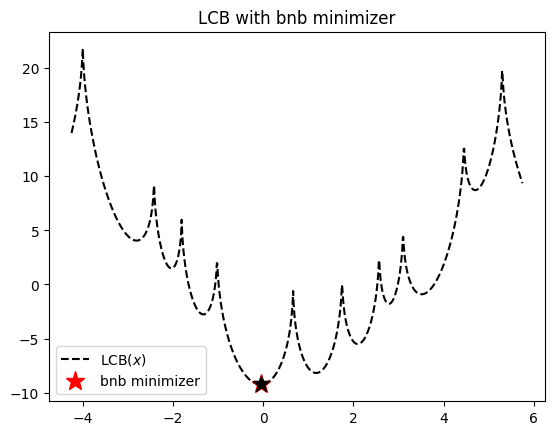

In [10]:
y_star = acqf.evaluate(xstar)
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
ystar_true = acqf.evaluate(xstar_true)
#print(xstar_true)
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
plt.plot(xstar_true, ystar_true, "k*", markersize=12)
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()


In [11]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'opt_solver': 'BnB',
    'solver_options' : solver_options,
}

In [12]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 3
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: BnB
hiopbbpy Internal optimization solver options: {'epsilon_diam': 1e-12, 'epsilon_gap': 0.01, 'max_iter': 4000}
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Logger level: INFO
hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 7.4670e-03 
hiopbbpy Best CONSTRAINED objective from 10 feasible initial samples: 7.4670e-03
hiopbbpy *****************************
hiopbbpy Iteration 1/3
hiopbbpy In batch 1/1
hiopbbpy Start finding the best sampling point:


=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -54.68337164144905
Initial acquisition upper bound: -4.630063957028471

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-54.68337164144905, U=-4.630063957028471
Current best feasible value (LUB): -4.630063957028471
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-35.82614596555674, U=2.450769622797492
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-36.47299694696554, U=0.3614294926374537
Queue size: 2 | LB=-36.47299694696554 | LUB=-4.630063957028471 | Gap<=31.842932989937065

--- BnB Iteration 2 ---
Node bounds: l=[0.75], u=[5.75]
Node acquisition bounds: L=-36.47299694696554, U=0.3614294926374537
Current best feasible value (LUB): -4.630063957028471
  Branching to child: l=[0.75], u=[3.25]
  Child acquisition bounds: L=-28.059624631737776, U

  Child acquisition bounds: L=-5.963058713413899, U=-0.7459245174267881
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.8125], u=[-0.5]
  Child acquisition bounds: L=-9.977776561514197, U=-6.397263668349764
Queue size: 14 | LB=-11.476454662789632 | LUB=-9.237696237094504 | Gap<=2.238758425695128

--- BnB Iteration 22 ---
Node bounds: l=[3.25], u=[4.5]
Node acquisition bounds: L=-11.476454662789632, U=0.609099361443409
Current best feasible value (LUB): -9.237696237094504
  Branching to child: l=[3.25], u=[3.875]
  Child acquisition bounds: L=-7.534854392080852, U=-0.8754602075385929
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[3.875], u=[4.5]
  Child acquisition bounds: L=-2.754817597278171, U=4.370258506912926
  Child pruned: L ≥ LUB + eps.
Queue size: 13 | LB=-11.043208596661286 | LUB=-9.237696237094504 | Gap<=1.805512359566782

--- BnB Iteration 23 ---
Node bounds: l=[0.75], u=[1.0625]
Node acquisition bounds: L=-11.043208596661286, U=-7.007124276785502
Current

  Child acquisition bounds: L=-8.967596023402036, U=-8.009082740489099
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.359375], u=[0.4375]
  Child acquisition bounds: L=-8.362302378819109, U=-7.3373977035422
  Child pruned: L ≥ LUB + eps.
Queue size: 19 | LB=-9.617262613860872 | LUB=-9.24178014227179 | Gap<=0.3754824715890823

--- BnB Iteration 44 ---
Node bounds: l=[-0.1484375], u=[-0.109375]
Node acquisition bounds: L=-9.617262613860872, U=-9.200463019966318
Current best feasible value (LUB): -9.24178014227179
  Branching to child: l=[-0.1484375], u=[-0.12890625]
  Child acquisition bounds: L=-9.397837113415754, U=-9.188907181164424
  Branching to child: l=[-0.12890625], u=[-0.109375]
  Child acquisition bounds: L=-9.419761870573439, U=-9.21060859368999
Queue size: 20 | LB=-9.615456366615135 | LUB=-9.24178014227179 | Gap<=0.37367622434334535

--- BnB Iteration 45 ---
Node bounds: l=[0.90625], u=[1.0625]
Node acquisition bounds: L=-9.615456366615135, U=-7.6174830404776355
Cu

  Child acquisition bounds: L=-9.261045790528463, U=-9.15350237410253
  Branching to child: l=[0.05664062], u=[0.06640625]
  Child acquisition bounds: L=-9.244060680192646, U=-9.136246666970674
Queue size: 32 | LB=-9.35957020080856 | LUB=-9.241889123593324 | Gap<=0.11768107721523613

--- BnB Iteration 67 ---
Node bounds: l=[2.], u=[2.3125]
Node acquisition bounds: L=-9.35957020080856, U=-5.4237217921838
Current best feasible value (LUB): -9.241889123593324
  Branching to child: l=[2.], u=[2.15625]
  Child acquisition bounds: L=-7.570843354685282, U=-5.4921094318939625
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[2.15625], u=[2.3125]
  Child acquisition bounds: L=-7.152917221531064, U=-5.080452705448369
  Child pruned: L ≥ LUB + eps.
Queue size: 31 | LB=-9.347273149720959 | LUB=-9.241889123593324 | Gap<=0.1053840261276342

--- BnB Iteration 68 ---
Node bounds: l=[-0.06054688], u=[-0.05078125]
Node acquisition bounds: L=-9.347273149720959, U=-9.241889123593324
Current best fea

...

  Child acquisition bounds: L=-6.037766575868017, U=-6.003446251355492
  Branching to child: l=[0.34228516], u=[0.34472656]
  Child acquisition bounds: L=-6.035415794340832, U=-6.001078758654708
Queue size: 36 | LB=-6.065709490738912 | LUB=-6.01180958642742 | Gap<=0.05389990431149183

--- BnB Iteration 102 ---
Node bounds: l=[0.29589844], u=[0.30078125]
Node acquisition bounds: L=-6.065709490738912, U=-5.997377021430245
Current best feasible value (LUB): -6.01180958642742
  Branching to child: l=[0.29589844], u=[0.29833984]
  Child acquisition bounds: L=-6.030093171218126, U=-5.995890630663415
  Branching to child: l=[0.29833984], u=[0.30078125]
  Child acquisition bounds: L=-6.032990706073189, U=-5.998790577774179
Queue size: 37 | LB=-6.065628234829749 | LUB=-6.01180958642742 | Gap<=0.05381864840232886

--- BnB Iteration 103 ---
Node bounds: l=[0.34472656], u=[0.34960938]
Node acquisition bounds: L=-6.065628234829749, U=-5.996971344459544
Current best feasible value (LUB): -6.01180958

  Child acquisition bounds: L=-6.020053267780087, U=-6.002882139869842
Queue size: 54 | LB=-6.03693214007954 | LUB=-6.01180958642742 | Gap<=0.02512255365212024

--- BnB Iteration 128 ---
Node bounds: l=[-0.4609375], u=[-0.421875]
Node acquisition bounds: L=-6.03693214007954, U=-5.540741518249108
Current best feasible value (LUB): -6.01180958642742
  Branching to child: l=[-0.4609375], u=[-0.44140625]
  Child acquisition bounds: L=-5.7929912574009785, U=-5.544105968635845
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.44140625], u=[-0.421875]
  Child acquisition bounds: L=-5.784463139806438, U=-5.534214899273238
  Child pruned: L ≥ LUB + eps.
Queue size: 53 | LB=-6.035597995055038 | LUB=-6.01180958642742 | Gap<=0.023788408627617663

--- BnB Iteration 129 ---
Node bounds: l=[0.30078125], u=[0.30322266]
Node acquisition bounds: L=-6.035597995055038, U=-6.001399230485938
Current best feasible value (LUB): -6.01180958642742
  Branching to child: l=[0.30078125], u=[0.30200195]
  

  Child acquisition bounds: L=-5.7736532993196334, U=-5.526634886533989
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.48046875], u=[-0.4609375]
  Child acquisition bounds: L=-5.789309840124402, U=-5.54149603136064
  Child pruned: L ≥ LUB + eps.
Queue size: 68 | LB=-6.027429504079728 | LUB=-6.01180958642742 | Gap<=0.015619917652307969

--- BnB Iteration 150 ---
Node bounds: l=[0.31420898], u=[0.31542969]
Node acquisition bounds: L=-6.027429504079728, U=-6.01031631187906
Current best feasible value (LUB): -6.01180958642742
  Branching to child: l=[0.31420898], u=[0.31481934]
  Child acquisition bounds: L=-6.018755983066957, U=-6.010197327842923
  Branching to child: l=[0.31481934], u=[0.31542969]
  Child acquisition bounds: L=-6.018989687846815, U=-6.010430739997838
Queue size: 69 | LB=-6.027353994430802 | LUB=-6.01180958642742 | Gap<=0.015544408003382415

--- BnB Iteration 151 ---
Node bounds: l=[0.33007812], u=[0.33129883]
Node acquisition bounds: L=-6.027353994430802, U=-

hiopbbpy   (mu, sigma) at new sample x: 0.3337335296536361, 2.1151810386936853 
hiopbbpy Best objective found in this iteration: 1.8254e-01 
hiopbbpy Training set size is now 13
hiopbbpy Current best objective: 1.7942e-01 (previous best: 1.7942e-01)
hiopbbpy Objective function improvement: 0.0000e+00
hiopbbpy ===================================
hiopbbpy Bayesian Optimization completed
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for BO iterations: 3
hiopbbpy Optimal at BO iteration: 2 
hiopbbpy Best value: 0.17942339181900024
hiopbbpy ===================================


  Child acquisition bounds: L=-6.013573442722145, U=-6.005017155785637
  Branching to child: l=[0.30627441], u=[0.30688477]
  Child acquisition bounds: L=-6.014061855682748, U=-6.005505506457301
Queue size: 78 | LB=-6.022262204995354 | LUB=-6.01180958642742 | Gap<=0.01045261856793367

--- BnB Iteration 170 ---
Node bounds: l=[0.27148438], u=[0.27636719]
Node acquisition bounds: L=-6.022262204995354, U=-5.953776644909649
Current best feasible value (LUB): -6.01180958642742
  Branching to child: l=[0.27148438], u=[0.27392578]
  Child acquisition bounds: L=-5.985111968721662, U=-5.950827196605362
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.27392578], u=[0.27636719]
  Child acquisition bounds: L=-5.990924234247669, U=-5.956652487375628
  Child pruned: L ≥ LUB + eps.
Queue size: 77 | LB=-6.02219084227831 | LUB=-6.01180958642742 | Gap<=0.010381255850890447

--- BnB Iteration 171 ---
Node bounds: l=[0.33862305], u=[0.33984375]
Node acquisition bounds: L=-6.02219084227831, U=-6.0

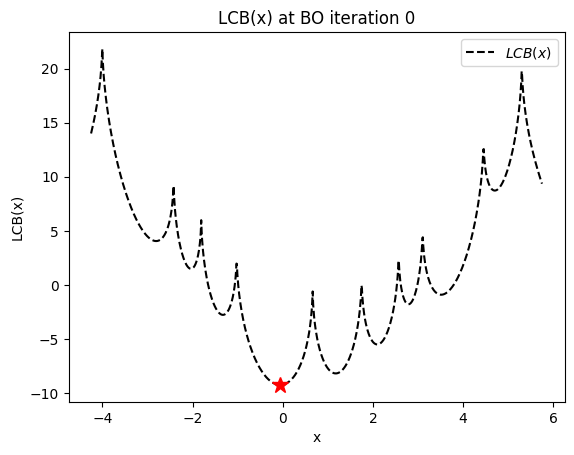

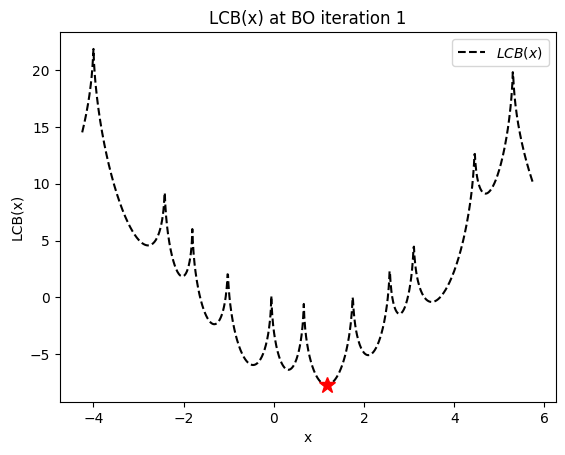

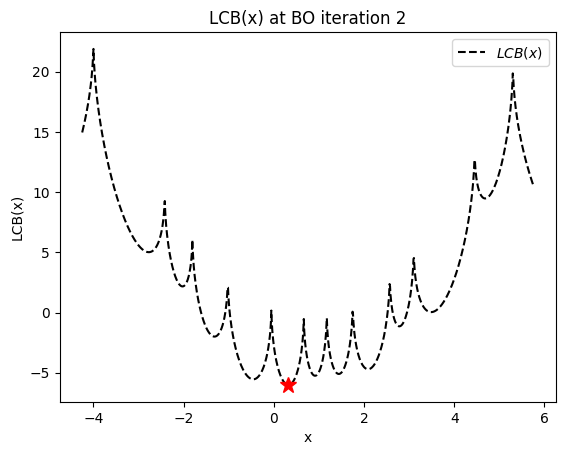

In [13]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    